# EDA Process & Feature Engineering
#### 1. Missing Values
#### 2. Explore About The Numerical Vriable
#### 3. Explore Categorical variable(how may categories are there)
#### 4. Finding Relationships between features

In [2]:
!pip install seaborn
import pandas as pandas
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
sales = pandas.read_csv("eabl parsed csv/eabl_sales_consolidated.csv")
sales

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153283,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Mis Plastic Container Ever,3.00,3
1153284,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Complete - M/P Amber In Lps,2.00,2
1153285,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Complete - M/P Ren Flint In Lps,2.00,2
1153286,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Smirnoff Cosmopolitan Cocktail 75cl 10Y 12X01,1.00,0


# Sales Data Eda
#### 1. Missing Values
#### 2. Explore About The Numerical Vriable
#### 3. Explore Categorical variable(how may categories are there)
#### 4. Finding Relationships between features

In [1034]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1153288 entries, 0 to 1153287
Data columns (total 9 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   source_file      1153288 non-null  str    
 1   salesperson      1153288 non-null  str    
 2   customer_code    1153288 non-null  str    
 3   cust_type        1153288 non-null  str    
 4   segment          1153286 non-null  str    
 5   visit_date       993617 non-null   str    
 6   product          1153288 non-null  str    
 7   quantity         1153288 non-null  float64
 8   return_quantity  1153288 non-null  int64  
dtypes: float64(1), int64(1), str(7)
memory usage: 79.2 MB


In [1035]:
sales.describe()

,quantity,return_quantity
count,1.153288e+06,1.153288e+06
mean,2.693060e+01,1.594696e+00
std,4.445434e+02,1.570681e+01
min,-9.761000e+01,0.000000e+00
25%,1.000000e+00,0.000000e+00
50%,2.000000e+00,0.000000e+00
75%,1.000000e+01,0.000000e+00
max,4.000000e+05,9.940000e+02


In [1036]:
print(sales.shape)

(1153288, 9)


<Axes: >

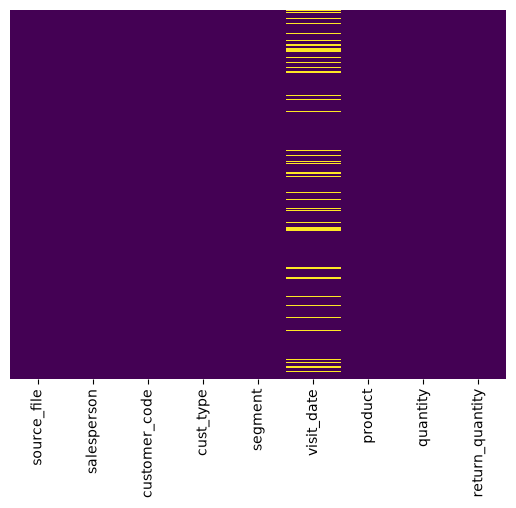

In [1037]:
sns.heatmap(sales.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [1038]:
sales.isnull().sum()

source_file             0
salesperson             0
customer_code           0
cust_type               0
segment                 2
visit_date         159671
product                 0
quantity                0
return_quantity         0
dtype: int64

In [1039]:
sales["visit_date"] = pandas.to_datetime(sales["visit_date"], format="%Y-%m-%d", errors="coerce")

In [1040]:
sales.dtypes

source_file                   str
salesperson                   str
customer_code                 str
cust_type                     str
segment                       str
visit_date         datetime64[us]
product                       str
quantity                  float64
return_quantity             int64
dtype: object

In [1041]:
sales["visit_date"].isnull().sum()

np.int64(159671)

In [1042]:
sales["visit_date"].dtype

dtype('<M8[us]')

In [1043]:
sales.dtypes

source_file                   str
salesperson                   str
customer_code                 str
cust_type                     str
segment                       str
visit_date         datetime64[us]
product                       str
quantity                  float64
return_quantity             int64
dtype: object

# Check for unique values in the customer_code column

In [1044]:
sales["customer_code"].value_counts().head(1000000)

customer_code
Total                42680
Sales Quantity       42669
Van closing Stock    37829
Van opening Stock    34892
KE0159054            14647
                     ...  
KE0142046                2
KE0062268                1
KE0062000                1
KE0062278                1
KE0171004                1
Name: count, Length: 954, dtype: int64

# Van Opening Stock Inspection


In [1045]:
sales.loc[sales["customer_code"].isin(["Van opening Stock"])]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
2611,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Smrnf Red 25Cl 40X01 Reggie,583.00,0
2612,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Guinness (K) Per Bottle,49.88,0
2613,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Tusker In Can 500ml CAN 24X01*,17.25,0
2614,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Gilbeys Gin 25Cl 40X01,604.00,0
2615,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,White Cap Crisp 300ml RET 25X01,29.00,0
...,...,...,...,...,...,...,...,...,...
1153245,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153246,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,Smirnoff Cosmopolitan Cocktail 75cl 10Y 12X01,2.00,0
1153247,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,J Wlkr Black 75Cl 12Y 12X01,3.00,0
1153248,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,Captain Morgan Long Island Cocktail 75cl 10Y 1...,2.00,0


In [1046]:
sales.loc[
    (sales["customer_code"].isin(["Van opening Stock"])) &
    (sales["visit_date"].isna())
]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
2611,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Smrnf Red 25Cl 40X01 Reggie,583.00,0
2612,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Guinness (K) Per Bottle,49.88,0
2613,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Tusker In Can 500ml CAN 24X01*,17.25,0
2614,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,Gilbeys Gin 25Cl 40X01,604.00,0
2615,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van opening Stock,Cash,Specialist Store,NaT,White Cap Crisp 300ml RET 25X01,29.00,0
...,...,...,...,...,...,...,...,...,...
1153245,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153246,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,Smirnoff Cosmopolitan Cocktail 75cl 10Y 12X01,2.00,0
1153247,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,J Wlkr Black 75Cl 12Y 12X01,3.00,0
1153248,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van opening Stock,Cash,Event,NaT,Captain Morgan Long Island Cocktail 75cl 10Y 1...,2.00,0


#### Find the Sum of the unique value Van Opening Stock whose dates are NaT

In [1047]:
(
    (sales["customer_code"].isin(["Van opening Stock"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(34892)

# Van Closing Stock Inspection

In [1048]:
sales.loc[sales["customer_code"].isin(["Van closing Stock"])]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
2823,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Smrnf Red 25Cl 40X01 Reggie,516.00,0
2824,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Guinness (K) Per Bottle,33.52,0
2825,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Tusker In Can 500ml CAN 24X01*,10.75,0
2826,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Gilbeys Gin 25Cl 40X01,493.00,0
2827,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,White Cap Crisp 300ml RET 25X01,23.00,0
...,...,...,...,...,...,...,...,...,...
1153283,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Mis Plastic Container Ever,3.00,3
1153284,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Complete - M/P Amber In Lps,2.00,2
1153285,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Complete - M/P Ren Flint In Lps,2.00,2
1153286,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Smirnoff Cosmopolitan Cocktail 75cl 10Y 12X01,1.00,0


In [1049]:
sales.loc[
    (sales["customer_code"].isin(["Van closing Stock"])) &
    (sales["visit_date"].isna())
]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
2823,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Smrnf Red 25Cl 40X01 Reggie,516.00,0
2824,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Guinness (K) Per Bottle,33.52,0
2825,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Tusker In Can 500ml CAN 24X01*,10.75,0
2826,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,Gilbeys Gin 25Cl 40X01,493.00,0
2827,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Van closing Stock,Cash,Specialist Store,NaT,White Cap Crisp 300ml RET 25X01,23.00,0
...,...,...,...,...,...,...,...,...,...
1153283,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Mis Plastic Container Ever,3.00,3
1153284,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Complete - M/P Amber In Lps,2.00,2
1153285,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Complete - M/P Ren Flint In Lps,2.00,2
1153286,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Smirnoff Cosmopolitan Cocktail 75cl 10Y 12X01,1.00,0


### Find the Sum of the unique value Van Closing Stock whose dates are NaT

In [1050]:
(
    (sales["customer_code"].isin(["Van closing Stock"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(37829)

## Sales Quantity Unique Value Inspection to Find the sum of visit_date which are NaT

In [1051]:
(
    (sales["customer_code"].isin(["Sales Quantity"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(42669)

In [1052]:
(
    (sales["customer_code"].isin(["Total"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(42680)

# Removing of NaT visit_date value rows since they are equally liked to the following:
### Total                46666
### Sales Quantity       42669
### Van closing Stock    41785
### Van opening Stock    34892
## Which are not actual customer codes

In [1053]:
sales = sales.dropna(subset=["visit_date"])

In [1054]:
sales.isnull().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            2
visit_date         0
product            0
quantity           0
return_quantity    0
dtype: int64

In [1055]:
sales

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153191,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Dbl Blck 1L 12X01,2.00,0
1153192,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153193,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Complete - M/P Amber In Lps,2.00,2
1153194,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Black 75Cl 12Y 12X01,3.00,0


# Salesperson Inspection

In [1056]:
sales["salesperson"].value_counts().head(1000000)

salesperson
ELISHA MARWA-TOWN B              109644
JOSPHAT ONDIGO-PIPELINE           95805
TONY MULEI-LANET                  93140
JOHN MWANGI-CBD                   91564
VINCENT MUSERA-OLK ROUTE          91258
KEY ACCOUNT                       86609
ERASTUS LIMO-BAHATIHESHIMA        83771
JOEL MAINA MWAURA-UDV VAN         73772
JOSEPH MWANIKI-KANU               72516
SEBASTIAN MUKHANZI-GILGIL         68340
ERIC KIAMA -OLK COUNTER           61552
WELDON KIRUI - NDUNDORI ROUTE     56837
Marvin Odhiambo                    3550
Vivian Jebiwott Yatich             2917
Martha  Mwende                     1190
Clare Wanyaga                       449
Barbara Mwatu                       302
Dennis Mutai                        138
Patrick Mukuna                      110
Evans Odero                          74
Norween  Kimalit                     41
Patricia Kinuthia                    26
Valentine Irungu                     12
Name: count, dtype: int64

# cust_type Inspection

In [1057]:
sales["cust_type"].value_counts().head(1000000)

cust_type
Cash      902227
Credit     91390
Name: count, dtype: int64

# Segment Inspection

In [1058]:
sales["segment"].value_counts().head(1000000)

segment
Bar                 483786
Specialist Store    401325
Wholesaler           35281
Event                20115
Lodging              14638
Nightclub            13448
Restaurant            7298
Marketplace           6579
Supermarket           5353
Recreation            3624
Convenience           2132
Not Applicable          36
Name: count, dtype: int64

In [1059]:
sales["product"].value_counts().head(1000000)

product
Euroform Amber Local 500ml               57490
Smirldb&Guarana 330ml Can 24X01          42613
Kenya Cane Lemon & Ginger 25cl 40X01     35657
Smirnf Ice PP R 330ml CAN 24X01 local    34298
Kenya Cane Pneap 25cl 40X01              32161
                                         ...  
Complete - Mop up empties                    1
Manyatta Sweet Cider 300ml 06X04 BBIC        1
Ciroc Red Berry 70cl      06X01              1
Singleton of Dufftown 70cl 21Y 04X01         1
JW GOT SngOfIce 1L 12X01 GOT                 1
Name: count, Length: 259, dtype: int64

In [1060]:
sales["quantity"].value_counts().head(1000000)

quantity
1.00     213680
2.00     111622
3.00      64897
5.00      64610
0.04      62645
          ...  
4.54          1
28.13         1
34.38         1
27.92         1
16.29         1
Name: count, Length: 1312, dtype: int64

# Will need normalization later

In [1061]:
sales["quantity"].describe()

count    993617.000000
mean         13.366132
std         471.931426
min         -48.000000
25%           0.600000
50%           2.000000
75%           5.000000
max      400000.000000
Name: quantity, dtype: float64

In [1062]:
print("skew:", sales["quantity"].skew())
print("rows where quantity <= 0:", (sales["quantity"] <= 0).sum())
print("99th percentile:", sales["quantity"].quantile(0.99))

skew: 650.0444634088283
rows where quantity <= 0: 99
99th percentile: 200.0


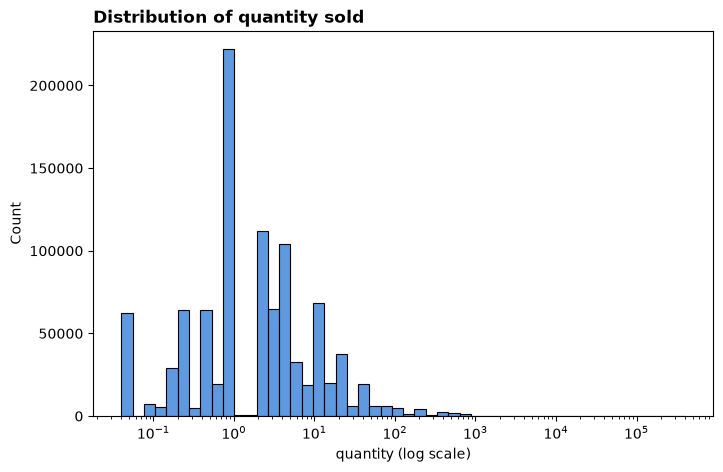

In [1063]:
positive_qty = sales.loc[sales["quantity"] > 0, "quantity"]

plt.figure(figsize=(8, 5))
sns.histplot(positive_qty, bins=50, log_scale=True, color="#2a78d6")
plt.xlabel("quantity (log scale)")
plt.title("Distribution of quantity sold", loc="left", fontsize=12, fontweight="bold")
plt.show()

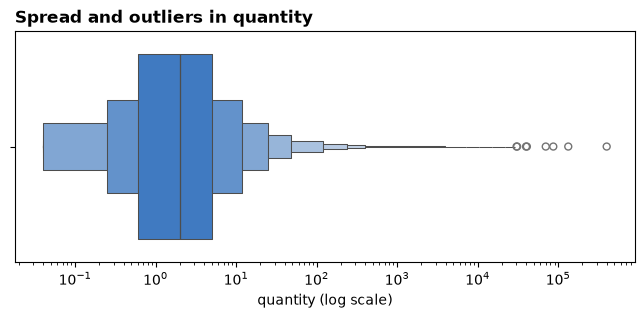

In [1064]:
plt.figure(figsize=(8, 3))
sns.boxenplot(x=positive_qty, color="#2a78d6")
plt.xscale("log")
plt.xlabel("quantity (log scale)")
plt.title("Spread and outliers in quantity", loc="left", fontsize=12, fontweight="bold")
plt.show()

In [1065]:
sales.isnull().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            2
visit_date         0
product            0
quantity           0
return_quantity    0
dtype: int64

In [1066]:
sales["segment"] = sales["segment"].fillna("Bar")

In [1118]:
sales[sales["segment"].isnull()]
merged_sales_customers

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity


In [1068]:
segment_pct = sales["segment"].value_counts(normalize=True) * 100
segment_pct


segment
Bar                 48.689586
Specialist Store    40.390311
Wholesaler           3.550765
Event                2.024422
Lodging              1.473203
Nightclub            1.353439
Restaurant           0.734488
Marketplace          0.662126
Supermarket          0.538739
Recreation           0.364728
Convenience          0.214570
Not Applicable       0.003623
Name: proportion, dtype: float64

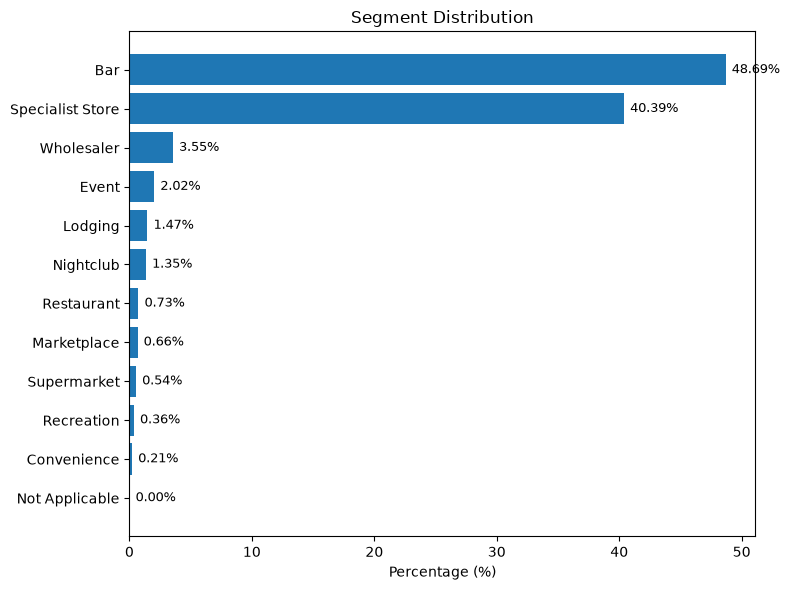

In [1069]:

segment_pct_sorted = segment_pct.sort_values()  # ascending, since barh draws bottom-up

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(segment_pct_sorted.index, segment_pct_sorted.values)

ax.set_xlabel("Percentage (%)")
ax.set_title("Segment Distribution")

# label each bar with its percentage
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{width:.2f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Bars and Specialist stores make up the majority of the Segment distribution

In [1070]:
sales.isnull().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            0
visit_date         0
product            0
quantity           0
return_quantity    0
dtype: int64

# Customer Dataset Eda
#### 1. Missing Values
#### 2. Explore About The Numerical Vriable
#### 3. Explore Categorical variable(how may categories are there)
#### 4. Finding Relationships between features

In [1071]:
pandas.set_option("display.max_columns", None)
customers = pandas.read_excel("EABL dataset/CustomerMaster.xlsx", skiprows=3)
customers

,Unnamed: 0,Distributor Code,Mode of Payment,DMS Customer Code,BE Customer Ref No,Unnamed: 5,Customer Name,Customer Name2,Cust Status,Customer Area,Price Group,global Channel,Sub-Channel,Segment,Sub-Segment 1,Sub-Segment 2,Sub-Segment 3,Sub-Segment 4,Volume Class,Volume Grade,Archi Type,OBOS,Division,Area,Territory,Route,Address,Contact Detail,Invoice Term,Cust Credit Limit,Outstanding Balance,Approval Status,Open Account Date,Cutsomer Type,RSS Flag,RSS Date Registed,RSS First Login Date,RSS Last Login Date,MPA Type,GPS Co-ordinate,Company Tax Registration Number,Outlet Visit Days,Contract Type,Contract Type – Hierarchy,Priority Brand,Last updated date-time,Terms and Conditions Policy,Privacy Policy,Cookies Policy
0,NaN,298703,Cash,KE0162873,NaN,NaN,GROUNDLESS LOUNGE,GROUNDLESS LOUNGE,INACTIVE,NaN,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,123 - Nightclub,009 - Modern Nightclub,009 - Premium,010 - High Energy,011 - High Energy Bar - Standard,NaN,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1002 - Dispatch-Stockiest,1 1 1 1 Kenya,,NaN,NaN,0.00,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,18/01/2023 10:36:07 AM,28/03/2024 07:33:59 AM,Trax,"36.0619485,-0.28986166",P052113412C,NaN,NaN,NaN,NaN,2025-09-16 16:12:22,Pending,Pending,Pending
1,NaN,298703,Cash,KE0162875,NaN,NaN,CONTAINER WINES,CONTAINER WINES,ACTIVE,NaN,UP02 - Upstream Stockiest Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,NaN,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1007 - Nakuru Town B,1 1 1 1 Kenya,,NaN,NaN,0.00,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,23/09/2024 06:57:05 AM,03/10/2025 12:29:36 PM,Trax,"36.06681044,-0.28723354",NaN,NaN,NaN,NaN,NaN,2025-08-07 10:15:05,Accepted,Accepted,Accepted
2,NaN,298703,Cash,KE0162877,NaN,NaN,BRUNO'S WINES,BRUNO'S WINES,INACTIVE,NaN,UP01 - Upstream Retail Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,NaN,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1012 - UDV Van,1 1 1 1 Kenya,,NaN,NaN,0.00,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,02/12/2022 03:06:31 PM,27/01/2023 11:51:45 AM,Trax,"36.06337491,-0.29006507",NaN,NaN,NaN,NaN,NaN,2024-02-13 12:55:09,Pending,Pending,Pending
3,NaN,298703,Cash,KE0162878,NaN,NaN,SURF AND SAND WINES,SURF AND SAND WINES,INACTIVE,NaN,UP02 - Upstream Stockiest Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,NaN,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1007 - Nakuru Town B,1 1 1 1 Kenya,,NaN,NaN,0.00,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,24/02/2023 01:53:18 PM,01/06/2025 03:24:14 PM,Trax,"36.06412856,-0.28478537",NaN,NaN,NaN,NaN,NaN,2025-09-09 19:16:03,Pending,Pending,Pending
4,NaN,298703,Cash,KE0162879,NaN,NaN,INFINITY WINES,INFINITY WINES,INACTIVE,NaN,UP02 - Upstream Stockiest Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,NaN,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1007 - Nakuru Town B,1 1 1 1 Kenya,,NaN,NaN,0.00,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,30/06/2023 08:14:20 AM,28/06/2024 08:20:04 AM,Trax,NaN,NaN,NaN,NaN,NaN,NaN,2025-0

### 1. Explore Missing Values

In [1072]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 49 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       0 non-null      float64
 1   Distributor Code                 2237 non-null   int64  
 2   Mode of Payment                  2237 non-null   str    
 3   DMS Customer Code                2237 non-null   str    
 4   BE Customer Ref No               640 non-null    str    
 5   Unnamed: 5                       0 non-null      float64
 6   Customer Name                    2237 non-null   str    
 7   Customer Name2                   1096 non-null   str    
 8   Cust Status                      2237 non-null   str    
 9   Customer Area                    0 non-null      float64
 10  Price Group                      2179 non-null   str    
 11  global Channel                   2237 non-null   str    
 12  Sub-Channel                    

In [1073]:
print(customers.shape)

(2237, 49)


In [1074]:
customers[customers["Cust Credit Limit"].notna()]

,Unnamed: 0,Distributor Code,Mode of Payment,DMS Customer Code,BE Customer Ref No,Unnamed: 5,Customer Name,Customer Name2,Cust Status,Customer Area,Price Group,global Channel,Sub-Channel,Segment,Sub-Segment 1,Sub-Segment 2,Sub-Segment 3,Sub-Segment 4,Volume Class,Volume Grade,Archi Type,OBOS,Division,Area,Territory,Route,Address,Contact Detail,Invoice Term,Cust Credit Limit,Outstanding Balance,Approval Status,Open Account Date,Cutsomer Type,RSS Flag,RSS Date Registed,RSS First Login Date,RSS Last Login Date,MPA Type,GPS Co-ordinate,Company Tax Registration Number,Outlet Visit Days,Contract Type,Contract Type – Hierarchy,Priority Brand,Last updated date-time,Terms and Conditions Policy,Privacy Policy,Cookies Policy
715,NaN,298703,Cash,KE0186654,NaN,NaN,Hollywood bar Kikopey,Hollywood Bar and restaurant,ACTIVE,NaN,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,NaN,G01 - Bronze,A1 - Rural Accessible,O8 - No Brand,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T088 - Gilgil,UPL1003 - Gilgil-Kikopey,gilgil kikopey nakuru kenya kenya,Peter Ndungu 0714221150,NaN,0.0,0.00,Approved,22/10/2025,Assigned,Yes,25/11/2025 01:10:09 AM,01/12/2025 11:20:01 AM,20/05/2026 09:21:17 PM,Trax,"36.04795776307583,-0.27729586232453585",NaN,NaN,NaN,NaN,NaN,2025-10-30 08:48:28,Pending,Pending,Pending
716,NaN,298703,Cash,KE0186655,NaN,NaN,Kamugunda Kikopey,Kamugunda bar,ACTIVE,NaN,UP03 - HYBRID,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,NaN,G01 - Bronze,A3 - Urban Accessible,O8 - No Brand,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T088 - Gilgil,UPL1003 - Gilgil-Kikopey,Kikopey Kikopey nakuru Kenya Kenya,Edward kamone 0703959481,NaN,0.0,0.00,Approved,22/10/2025,Assigned,Yes,25/11/2025 01:10:09 AM,01/12/2025 11:03:39 AM,02/01/2026 11:34:09 AM,Trax,"36.04795776307583,-0.27729586232453585",NaN,NaN,NaN,NaN,NaN,2025-10-30 08:49:35,Pending,Pending,Pending
796,NaN,298703,Cash,KE0188685,NaN,NaN,Club cocktail gilgil highway,club cocktail city,ACTIVE,NaN,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,NaN,G01 - Bronze,A1 - Rural Accessible,O4 - Balozi,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T088 - Gilgil,UPL1003 - Gilgil-Kikopey,gilgil 1 nakuru Kenya Kenya,Mary Naini 0714451905,NaN,0.0,0.00,Approved,14/11/2025,Assigned,Yes,12/12/2025 01:08:15 AM,23/12/2025 03:07:27 PM,15/06/2026 09:27:06 AM,Trax,"36.0477164,-0.2776542",NaN,NaN,NaN,NaN,NaN,2025-11-27 13:01:09,Pending,Pending,Pending
797,NaN,298703,Cash,KE0188686,NaN,NaN,Oldies Goshen Restaurant Gilgil,Oldies Goshen Restaurant,ACTIVE,NaN,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,013 - Nyama Joint,016 - Nyama Joint - Rift,NaN,X - Not Defined,A1 - Rural Accessible,O8 - No Brand,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T088 - Gilgil,UPL1003 - Gilgil-Kikopey,Gilgil-Town 1 1 gilgil 1,Diana and Esther 0714669447 0719193382,NaN,0.0,0.00,Approved,07/10/2025,Assigned,No,NaN,NaN,NaN,Trax,"36.04794812388718,-0.2773189963772893",NaN,5,NaN,NaN,NaN,2025-11-27 13:02:58,Pending,Pending,Pending
798,NaN,298703,Cash,KE0188688,NaN,NaN,"Favour Pub,Heshima",Favour Pub Heshima,ACTIVE,NaN,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,014 - Makutano,021 - Makutano - Rift,NaN,G01 - Bronze,A1 - Rural Accessible,O8 - No Brand,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T089 - Lanet,UPL1001 - Bahati-Heshima,heshima 1 Nakuru nakuru kenya,Alex Kamau 0702733173,NaN,0.0,0.00,Approved,24/11/2025,Assigned,Yes,12/12/2025 01:08:15 AM,15/06/2026 01:05:02 PM,26/06/2026 11:27:12 PM,Trax,"36.0484151,-0.2771803",NaN,NaN,NaN,NaN,NaN,2025-11-27 13:05:24,Pending,Pending,Pending
...,

In [1075]:
customers.isnull().sum()

Unnamed: 0                         2237
Distributor Code                      0
Mode of Payment                       0
DMS Customer Code                     0
BE Customer Ref No                 1597
Unnamed: 5                         2237
Customer Name                         0
Customer Name2                     1141
Cust Status                           0
Customer Area                      2237
Price Group                          58
global Channel                        0
Sub-Channel                           0
Segment                               0
Sub-Segment 1                         0
Sub-Segment 2                         0
Sub-Segment 3                         0
Sub-Segment 4                         0
Volume Class                       2237
Volume Grade                          0
Archi Type                            0
OBOS                                  0
Division                              0
Area                                  0
Territory                             0


In [1076]:
missing_pct = customers.isnull().mean()
missing_pct

Unnamed: 0                         1.000000
Distributor Code                   0.000000
Mode of Payment                    0.000000
DMS Customer Code                  0.000000
BE Customer Ref No                 0.713903
Unnamed: 5                         1.000000
Customer Name                      0.000000
Customer Name2                     0.510058
Cust Status                        0.000000
Customer Area                      1.000000
Price Group                        0.025928
global Channel                     0.000000
Sub-Channel                        0.000000
Segment                            0.000000
Sub-Segment 1                      0.000000
Sub-Segment 2                      0.000000
Sub-Segment 3                      0.000000
Sub-Segment 4                      0.000000
Volume Class                       1.000000
Volume Grade                       0.000000
Archi Type                         0.000000
OBOS                               0.000000
Division                        

In [1077]:
cols_to_drop = missing_pct[missing_pct > 0.5].index   # drop columns >50% empty
customers_clean = customers.drop(columns=cols_to_drop)
customers_clean.isnull().sum()

Distributor Code                 0
Mode of Payment                  0
DMS Customer Code                0
Customer Name                    0
Cust Status                      0
Price Group                     58
global Channel                   0
Sub-Channel                      0
Segment                          0
Sub-Segment 1                    0
Sub-Segment 2                    0
Sub-Segment 3                    0
Sub-Segment 4                    0
Volume Grade                     0
Archi Type                       0
OBOS                             0
Division                         0
Area                             0
Territory                        0
Route                            0
Address                          0
Contact Detail                   0
Outstanding Balance             11
Approval Status                  0
Open Account Date                0
Cutsomer Type                    0
RSS Flag                         0
RSS Date Registed              409
RSS First Login Date

#### i.) Price Group Exploration

In [1078]:
customers_clean[customers_clean["Price Group"].isna()]


,Distributor Code,Mode of Payment,DMS Customer Code,Customer Name,Cust Status,Price Group,global Channel,Sub-Channel,Segment,Sub-Segment 1,Sub-Segment 2,Sub-Segment 3,Sub-Segment 4,Volume Grade,Archi Type,OBOS,Division,Area,Territory,Route,Address,Contact Detail,Outstanding Balance,Approval Status,Open Account Date,Cutsomer Type,RSS Flag,RSS Date Registed,RSS First Login Date,RSS Last Login Date,MPA Type,GPS Co-ordinate,Last updated date-time,Terms and Conditions Policy,Privacy Policy,Cookies Policy
18,298703,Cash,KE0163144,ILE PLACE CHILL SPOT WHITEHOUSE,INACTIVE,NaN,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T089 - Lanet,NA - Unknown,1 1 1 1 Kenya,,0.0,Approved,25/11/2022,Assigned,Yes,26/01/2023 05:18:57 AM,NaN,NaN,Trax,NaN,2023-06-22 10:01:43,Pending,Pending,Pending
65,298703,Cash,KE0023582,"Pewa, Gilgil Syndicate",INACTIVE,NaN,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,014 - Makutano,021 - Makutano - Rift,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T088 - Gilgil,NA - Unknown,Gilgil Syndicate Addr2 Gilgil Addr4 Kenya,,0.0,Approved,01/09/2015,Assigned,Yes,23/11/2020 06:06:11 AM,22/11/2021 01:20:14 PM,22/11/2021 01:20:14 PM,Trax,"36.32815948,-0.49687092",2022-04-14 10:14:15,Pending,Pending,Pending
71,298703,Cash,KE0026256,"Flavours Lounge, Gilgil Hwy",INACTIVE,NaN,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,014 - Makutano,021 - Makutano - Rift,X - Not Defined,A1 - Rural Accessible,O1 - Tusker Lager,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T088 - Gilgil,NA - Unknown,Gilgil Highway Addr2 Gilgil Addr4 Kenya,,0.0,Approved,01/09/2015,Assigned,Yes,23/11/2020 06:06:11 AM,25/01/2021 01:23:49 PM,25/01/2021 01:23:49 PM,Trax,"36.31321008,-0.49901655",2022-02-09 16:11:37,Pending,Pending,Pending
72,298703,Cash,KE0026257,"Migingo Gilgil, Gilgil Hwy",INACTIVE,NaN,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,X - Not Defined,A1 - Rural Accessible,O1 - Tusker Lager,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T088 - Gilgil,NA - Unknown,Gilgil Highway Addr2 Gilgil Addr4 Kenya,,0.0,Approved,01/09/2015,Assigned,Yes,23/11/2020 06:06:11 AM,NaN,NaN,Trax,"36.31469085,-0.50208714",2022-02-09 16:12:00,Pending,Pending,Pending
75,298703,Cash,KE0026264,"Sunset, Gilgil Stage",INACTIVE,NaN,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,X - Not Defined,A1 - Rural Accessible,O1 - Tusker Lager,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T088 - Gilgil,NA - Unknown,Gilgil Stage Addr2 Gilgil Addr4 Kenya,,0.0,Approved,01/09/2015,Assigned,Yes,NaN,NaN,NaN,Trax,"36.3284049,-0.5027708",2022-02-09 16:07:19,Pending,Pending,Pending
76,298703,Cash,KE0026265,"Addis, Gilgil Stage",INACTIVE,NaN,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,X - Not Defined,A1 - Rural Accessible,O1 - Tusker Lager,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T088 - Gilgil,NA - Unknown,Gilgil Stage Addr2 Gilgil Addr4 Kenya,,0.0,Approved,01/09/2015,Assigned,Yes,NaN,NaN,NaN,Trax,"36.32734217,-0.50104926",2022-02-09 16:07:40,Pending,Pending,Pending
77,298703,Cash,KE0026267,"Accacia Shepmatt, Gilgil",INACTIVE,NaN,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,014 - Makutano,021 - Makutano - Rift,X - Not Defined,A1 - Rural Accessible,O1 - Tusker Lager,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T088 - Gilgil,NA - Unknown,1 1 Nakuru Nakuru Kenya,,0.0,Approved,01/09/2015,Assigned,Yes,NaN,NaN,NaN,Trax,"36.35973674,-0.4878

In [1079]:
customers_clean[customers_clean["Price Group"].notna()]


,Distributor Code,Mode of Payment,DMS Customer Code,Customer Name,Cust Status,Price Group,global Channel,Sub-Channel,Segment,Sub-Segment 1,Sub-Segment 2,Sub-Segment 3,Sub-Segment 4,Volume Grade,Archi Type,OBOS,Division,Area,Territory,Route,Address,Contact Detail,Outstanding Balance,Approval Status,Open Account Date,Cutsomer Type,RSS Flag,RSS Date Registed,RSS First Login Date,RSS Last Login Date,MPA Type,GPS Co-ordinate,Last updated date-time,Terms and Conditions Policy,Privacy Policy,Cookies Policy
0,298703,Cash,KE0162873,GROUNDLESS LOUNGE,INACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,123 - Nightclub,009 - Modern Nightclub,009 - Premium,010 - High Energy,011 - High Energy Bar - Standard,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1002 - Dispatch-Stockiest,1 1 1 1 Kenya,,0.00,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,18/01/2023 10:36:07 AM,28/03/2024 07:33:59 AM,Trax,"36.0619485,-0.28986166",2025-09-16 16:12:22,Pending,Pending,Pending
1,298703,Cash,KE0162875,CONTAINER WINES,ACTIVE,UP02 - Upstream Stockiest Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1007 - Nakuru Town B,1 1 1 1 Kenya,,0.00,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,23/09/2024 06:57:05 AM,03/10/2025 12:29:36 PM,Trax,"36.06681044,-0.28723354",2025-08-07 10:15:05,Accepted,Accepted,Accepted
2,298703,Cash,KE0162877,BRUNO'S WINES,INACTIVE,UP01 - Upstream Retail Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1012 - UDV Van,1 1 1 1 Kenya,,0.00,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,02/12/2022 03:06:31 PM,27/01/2023 11:51:45 AM,Trax,"36.06337491,-0.29006507",2024-02-13 12:55:09,Pending,Pending,Pending
3,298703,Cash,KE0162878,SURF AND SAND WINES,INACTIVE,UP02 - Upstream Stockiest Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1007 - Nakuru Town B,1 1 1 1 Kenya,,0.00,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,24/02/2023 01:53:18 PM,01/06/2025 03:24:14 PM,Trax,"36.06412856,-0.28478537",2025-09-09 19:16:03,Pending,Pending,Pending
4,298703,Cash,KE0162879,INFINITY WINES,INACTIVE,UP02 - Upstream Stockiest Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1007 - Nakuru Town B,1 1 1 1 Kenya,,0.00,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,30/06/2023 08:14:20 AM,28/06/2024 08:20:04 AM,Trax,NaN,2025-02-18 15:36:31,Pending,Pending,Pending
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,298703,Cash,KE0162646,"New Yako, Nakuru",ACTIVE,UP_S000007 - REBATE PRICE GROUP T1,008 - Route to Market,031 - Wholesaler,119 - Wholesaler,004 - Modern Wholesaler,004 - Wines & Spirits,005 - Wholesaler,005 - Wholesaler,G04 - Platinum,A3 - Urban Accessible,O8 - No Brand,DGO-D06 - Rift,DGO-D06-A58 - Rift Key Accounts,DGO-D06-A58-T760 - KSO North Rift,UPL1002 

In [1080]:
customers_clean["Price Group"].value_counts()

Price Group
UP01 - Upstream Retail Price List          1421
UP02 - Upstream Stockiest Price List        471
UP03 - HYBRID                               256
UP04 - HYBRID 2-SUPER S                      14
UP_S000001 - Upstream Hybrid 3 -SUPER-S       7
UP_S000007 - REBATE PRICE GROUP T1            7
UP_S000002 - Black November                   2
UP_S000005 - Hybrid 5-JR                      1
Name: count, dtype: int64

In [1081]:
customers_clean.isnull().sum()

Distributor Code                 0
Mode of Payment                  0
DMS Customer Code                0
Customer Name                    0
Cust Status                      0
Price Group                     58
global Channel                   0
Sub-Channel                      0
Segment                          0
Sub-Segment 1                    0
Sub-Segment 2                    0
Sub-Segment 3                    0
Sub-Segment 4                    0
Volume Grade                     0
Archi Type                       0
OBOS                             0
Division                         0
Area                             0
Territory                        0
Route                            0
Address                          0
Contact Detail                   0
Outstanding Balance             11
Approval Status                  0
Open Account Date                0
Cutsomer Type                    0
RSS Flag                         0
RSS Date Registed              409
RSS First Login Date

#### ii.) Outstanding Balance Exploration

In [1082]:
customers_clean["Outstanding Balance"].isnull().sum()

np.int64(11)

In [1083]:
customers_clean.isnull().sum()

Distributor Code                 0
Mode of Payment                  0
DMS Customer Code                0
Customer Name                    0
Cust Status                      0
Price Group                     58
global Channel                   0
Sub-Channel                      0
Segment                          0
Sub-Segment 1                    0
Sub-Segment 2                    0
Sub-Segment 3                    0
Sub-Segment 4                    0
Volume Grade                     0
Archi Type                       0
OBOS                             0
Division                         0
Area                             0
Territory                        0
Route                            0
Address                          0
Contact Detail                   0
Outstanding Balance             11
Approval Status                  0
Open Account Date                0
Cutsomer Type                    0
RSS Flag                         0
RSS Date Registed              409
RSS First Login Date

In [1084]:
customers_clean[customers_clean["Outstanding Balance"].isna()]


,Distributor Code,Mode of Payment,DMS Customer Code,Customer Name,Cust Status,Price Group,global Channel,Sub-Channel,Segment,Sub-Segment 1,Sub-Segment 2,Sub-Segment 3,Sub-Segment 4,Volume Grade,Archi Type,OBOS,Division,Area,Territory,Route,Address,Contact Detail,Outstanding Balance,Approval Status,Open Account Date,Cutsomer Type,RSS Flag,RSS Date Registed,RSS First Login Date,RSS Last Login Date,MPA Type,GPS Co-ordinate,Last updated date-time,Terms and Conditions Policy,Privacy Policy,Cookies Policy
1740,298703,Cash,KE0145362,"Andys Pub, Karunga",INACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,X - Not Defined,A3 - Urban Accessible,O3 - Pilsner,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T088 - Gilgil,NA - Unknown,1 Addr2 Addr3 Addr4 Kenya,,NaN,Pending,30/09/2020,Assigned,Yes,30/01/2021 06:01:53 AM,NaN,NaN,Trax,NaN,2021-07-09 14:07:12,Pending,Pending,Pending
1741,298703,Cash,KE0145363,"Savannah W&S, Subukia",INACTIVE,UP01 - Upstream Retail Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,118 - Cash and Carry Rift - Tier 2,X - Not Defined,A3 - Urban Accessible,O8 - No Brand,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T089 - Lanet,NA - Unknown,1 Addr2 Addr3 Addr4 Kenya,,NaN,Pending,30/09/2020,Assigned,Yes,30/01/2021 06:01:53 AM,NaN,NaN,Trax,NaN,2022-03-17 10:22:47,Pending,Pending,Pending
1742,298703,Cash,KE0145364,beer store tumain,INACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,X - Not Defined,A1 - Rural Accessible,O4 - Balozi,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T088 - Gilgil,UPL1009 - Olkalao,1 Addr2 Addr3 Addr4 Kenya,,NaN,Pending,30/09/2020,Assigned,Yes,30/01/2021 06:01:53 AM,NaN,NaN,Trax,NaN,2021-10-29 10:23:27,Pending,Pending,Pending
1743,298703,Cash,KE0145365,"KEG CENTRE,CHAGITHA",INACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,X - Not Defined,A1 - Rural Accessible,O1 - Tusker Lager,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T088 - Gilgil,NA - Unknown,1 Addr2 Addr3 Addr4 Kenya,,NaN,Pending,30/09/2020,Assigned,Yes,30/01/2021 06:01:53 AM,NaN,NaN,Trax,NaN,2021-10-29 10:23:42,Pending,Pending,Pending
1754,298703,Cash,KE0145376,"RASTA ,SUPERMARKET OLK",INACTIVE,UP02 - Upstream Stockiest Price List,002 - Off Trade,035 - Retailer,129 - Supermarket,024 - Traditional Supermarket,026 - Grocery,027 - Superette,129 - Grocery Rift,X - Not Defined,A3 - Urban Accessible,O9 - Staff,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T088 - Gilgil,NA - Unknown,1 Addr2 Addr3 Addr4 Kenya,,NaN,Pending,30/09/2020,Assigned,Yes,30/01/2021 06:01:53 AM,NaN,NaN,Trax,NaN,2022-03-18 11:04:43,Pending,Pending,Pending
1755,298703,Cash,KE0145377,"Caravan, Gilgil",INACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,X - Not Defined,A3 - Urban Accessible,O1 - Tusker Lager,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T088 - Gilgil,NA - Unknown,1 1 1 1 Kenya,,NaN,Pending,30/09/2020,Assigned,Yes,31/01/2021 06:01:57 AM,NaN,NaN,Trax,NaN,2022-03-19 21:03:53,Pending,Pending,Pending
1756,298703,Cash,KE0145378,Rift Valley Motors & Sports Club,INACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,127 - Event,020 - Modern Event,022 - DTEU,023 - 3rd Space,045 - 3rd Space,X - Not Defined,A1 - Rural Accessible,O1 - Tusker Lager,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T089 - Lanet,NA - Unknown,1 Addr2 Addr3 Addr4 Kenya,,NaN,Pending,30/09/2020,Assigned,Yes,30/01/2021 06:01:53 AM,NaN,NaN,Trax,NaN,2021-10-09 11:07:12,Pending,Pending,Pend

In [1085]:
customers_clean.isnull().sum()

Distributor Code                 0
Mode of Payment                  0
DMS Customer Code                0
Customer Name                    0
Cust Status                      0
Price Group                     58
global Channel                   0
Sub-Channel                      0
Segment                          0
Sub-Segment 1                    0
Sub-Segment 2                    0
Sub-Segment 3                    0
Sub-Segment 4                    0
Volume Grade                     0
Archi Type                       0
OBOS                             0
Division                         0
Area                             0
Territory                        0
Route                            0
Address                          0
Contact Detail                   0
Outstanding Balance             11
Approval Status                  0
Open Account Date                0
Cutsomer Type                    0
RSS Flag                         0
RSS Date Registed              409
RSS First Login Date

In [1086]:
customers_clean["Outstanding Balance"] = customers_clean["Outstanding Balance"].fillna(0)

In [1087]:
customers_clean.isnull().sum()

Distributor Code                 0
Mode of Payment                  0
DMS Customer Code                0
Customer Name                    0
Cust Status                      0
Price Group                     58
global Channel                   0
Sub-Channel                      0
Segment                          0
Sub-Segment 1                    0
Sub-Segment 2                    0
Sub-Segment 3                    0
Sub-Segment 4                    0
Volume Grade                     0
Archi Type                       0
OBOS                             0
Division                         0
Area                             0
Territory                        0
Route                            0
Address                          0
Contact Detail                   0
Outstanding Balance              0
Approval Status                  0
Open Account Date                0
Cutsomer Type                    0
RSS Flag                         0
RSS Date Registed              409
RSS First Login Date

In [1088]:
customers_clean[customers_clean["RSS First Login Date"].isna()]

,Distributor Code,Mode of Payment,DMS Customer Code,Customer Name,Cust Status,Price Group,global Channel,Sub-Channel,Segment,Sub-Segment 1,Sub-Segment 2,Sub-Segment 3,Sub-Segment 4,Volume Grade,Archi Type,OBOS,Division,Area,Territory,Route,Address,Contact Detail,Outstanding Balance,Approval Status,Open Account Date,Cutsomer Type,RSS Flag,RSS Date Registed,RSS First Login Date,RSS Last Login Date,MPA Type,GPS Co-ordinate,Last updated date-time,Terms and Conditions Policy,Privacy Policy,Cookies Policy
5,298703,Cash,KE0162880,FRIENDS BAR,INACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1004 - Kanu-Kaptembwa,1 1 1 1 Kenya,,0.0,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,NaN,NaN,Trax,NaN,2024-02-13 12:53:47,Pending,Pending,Pending
10,298703,Cash,KE0162967,BRINKEY LOUNGE PIPELINE,INACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T089 - Lanet,NA - Unknown,1 1 1 1 Kenya,,0.0,Approved,23/11/2022,Assigned,Yes,24/11/2022 01:04:01 AM,NaN,NaN,Trax,"36.1429236,-0.3202532",2022-11-24 16:47:06,Pending,Pending,Pending
16,298703,Cash,KE0163086,Downtown Bar Kenlands,INACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T093 - Nakuru West,UPL1004 - Kanu-Kaptembwa,1 1 1 1 Kenya,,0.0,Approved,24/11/2022,Assigned,Yes,25/11/2022 01:04:07 AM,NaN,NaN,Trax,"36.06020847,-0.29820835",2022-11-24 16:47:28,Pending,Pending,Pending
17,298703,Cash,KE0163128,Spirit of the Season,INACTIVE,UP_S000002 - Black November,001 - On Trade,034 - On Trade,127 - Event,020 - Modern Event,022 - DTEU,023 - 3rd Space,045 - 3rd Space,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T089 - Lanet,NA - Unknown,Bahati Bahati Bahati Bahati Kenya,,0.0,Approved,24/11/2022,Assigned,Yes,25/11/2022 01:04:07 AM,NaN,NaN,Trax,NaN,2023-01-07 21:23:52,Pending,Pending,Pending
18,298703,Cash,KE0163144,ILE PLACE CHILL SPOT WHITEHOUSE,INACTIVE,NaN,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T089 - Lanet,NA - Unknown,1 1 1 1 Kenya,,0.0,Approved,25/11/2022,Assigned,Yes,26/01/2023 05:18:57 AM,NaN,NaN,Trax,NaN,2023-06-22 10:01:43,Pending,Pending,Pending
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2222,298703,Cash,KE0161034,Dream City,INACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,014 - Makutano,021 - Makutano - Rift,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,NA - Unknown,1 1 1 1 Kenya,,0.0,Approved,11/10/2022,Assigned,Yes,12/10/2022 01:03:58 AM,NaN,NaN,Trax,"36.06151666,-0.29041438",2023-08-15 15:48:23,Pending,Pending,Pending
2223,298703,Cash,KE0161232,"MIGINGO BAR,GWA KIONGO",INACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17

In [1089]:
customers_clean["rss_ever_logged_in"] = customers_clean["RSS First Login Date"].notna()
customers_clean["rss_last_logged_in"] = customers_clean["RSS Last Login Date"].notna()
customers_clean["rss_date_registered"] = customers_clean["RSS Date Registed"].notna()
customers_clean = customers_clean.drop(columns=["GPS Co-ordinate"])
customers_clean

,Distributor Code,Mode of Payment,DMS Customer Code,Customer Name,Cust Status,Price Group,global Channel,Sub-Channel,Segment,Sub-Segment 1,Sub-Segment 2,Sub-Segment 3,Sub-Segment 4,Volume Grade,Archi Type,OBOS,Division,Area,Territory,Route,Address,Contact Detail,Outstanding Balance,Approval Status,Open Account Date,Cutsomer Type,RSS Flag,RSS Date Registed,RSS First Login Date,RSS Last Login Date,MPA Type,Last updated date-time,Terms and Conditions Policy,Privacy Policy,Cookies Policy,rss_ever_logged_in,rss_last_logged_in,rss_date_registered
0,298703,Cash,KE0162873,GROUNDLESS LOUNGE,INACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,123 - Nightclub,009 - Modern Nightclub,009 - Premium,010 - High Energy,011 - High Energy Bar - Standard,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1002 - Dispatch-Stockiest,1 1 1 1 Kenya,,0.00,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,18/01/2023 10:36:07 AM,28/03/2024 07:33:59 AM,Trax,2025-09-16 16:12:22,Pending,Pending,Pending,True,True,True
1,298703,Cash,KE0162875,CONTAINER WINES,ACTIVE,UP02 - Upstream Stockiest Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1007 - Nakuru Town B,1 1 1 1 Kenya,,0.00,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,23/09/2024 06:57:05 AM,03/10/2025 12:29:36 PM,Trax,2025-08-07 10:15:05,Accepted,Accepted,Accepted,True,True,True
2,298703,Cash,KE0162877,BRUNO'S WINES,INACTIVE,UP01 - Upstream Retail Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1012 - UDV Van,1 1 1 1 Kenya,,0.00,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,02/12/2022 03:06:31 PM,27/01/2023 11:51:45 AM,Trax,2024-02-13 12:55:09,Pending,Pending,Pending,True,True,True
3,298703,Cash,KE0162878,SURF AND SAND WINES,INACTIVE,UP02 - Upstream Stockiest Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1007 - Nakuru Town B,1 1 1 1 Kenya,,0.00,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,24/02/2023 01:53:18 PM,01/06/2025 03:24:14 PM,Trax,2025-09-09 19:16:03,Pending,Pending,Pending,True,True,True
4,298703,Cash,KE0162879,INFINITY WINES,INACTIVE,UP02 - Upstream Stockiest Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1007 - Nakuru Town B,1 1 1 1 Kenya,,0.00,Approved,21/11/2022,Assigned,Yes,22/11/2022 01:04:04 AM,30/06/2023 08:14:20 AM,28/06/2024 08:20:04 AM,Trax,2025-02-18 15:36:31,Pending,Pending,Pending,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,298703,Cash,KE0162646,"New Yako, Nakuru",ACTIVE,UP_S000007 - REBATE PRICE GROUP T1,008 - Route to Market,031 - Wholesaler,119 - Wholesaler,004 - Modern Wholesaler,004 - Wines & Spirits,005 - Wholesaler,005 - Wholesaler,G04 - Platinum,A3 - Urban Accessible,O8 - No Brand,DGO-D06 - Rift,DGO-D06-A58 - Rift Key Accounts,DGO-D06-A58-T760 - KSO N

In [1090]:
customers_clean["RSS First Login Date"] = pandas.to_datetime(
    customers_clean["RSS First Login Date"], format="%d/%m/%Y %I:%M:%S %p", errors="coerce"
)
customers_clean["RSS Last Login Date"] = pandas.to_datetime(
    customers_clean["RSS Last Login Date"], format="%d/%m/%Y %I:%M:%S %p", errors="coerce"
)
customers_clean["RSS Date Registed"] = pandas.to_datetime(
    customers_clean["RSS Date Registed"], format="%d/%m/%Y %I:%M:%S %p", errors="coerce"
)
customers_clean

,Distributor Code,Mode of Payment,DMS Customer Code,Customer Name,Cust Status,Price Group,global Channel,Sub-Channel,Segment,Sub-Segment 1,Sub-Segment 2,Sub-Segment 3,Sub-Segment 4,Volume Grade,Archi Type,OBOS,Division,Area,Territory,Route,Address,Contact Detail,Outstanding Balance,Approval Status,Open Account Date,Cutsomer Type,RSS Flag,RSS Date Registed,RSS First Login Date,RSS Last Login Date,MPA Type,Last updated date-time,Terms and Conditions Policy,Privacy Policy,Cookies Policy,rss_ever_logged_in,rss_last_logged_in,rss_date_registered
0,298703,Cash,KE0162873,GROUNDLESS LOUNGE,INACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,123 - Nightclub,009 - Modern Nightclub,009 - Premium,010 - High Energy,011 - High Energy Bar - Standard,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1002 - Dispatch-Stockiest,1 1 1 1 Kenya,,0.00,Approved,21/11/2022,Assigned,Yes,2022-11-22 01:04:04,2023-01-18 10:36:07,2024-03-28 07:33:59,Trax,2025-09-16 16:12:22,Pending,Pending,Pending,True,True,True
1,298703,Cash,KE0162875,CONTAINER WINES,ACTIVE,UP02 - Upstream Stockiest Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1007 - Nakuru Town B,1 1 1 1 Kenya,,0.00,Approved,21/11/2022,Assigned,Yes,2022-11-22 01:04:04,2024-09-23 06:57:05,2025-10-03 12:29:36,Trax,2025-08-07 10:15:05,Accepted,Accepted,Accepted,True,True,True
2,298703,Cash,KE0162877,BRUNO'S WINES,INACTIVE,UP01 - Upstream Retail Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1012 - UDV Van,1 1 1 1 Kenya,,0.00,Approved,21/11/2022,Assigned,Yes,2022-11-22 01:04:04,2022-12-02 15:06:31,2023-01-27 11:51:45,Trax,2024-02-13 12:55:09,Pending,Pending,Pending,True,True,True
3,298703,Cash,KE0162878,SURF AND SAND WINES,INACTIVE,UP02 - Upstream Stockiest Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1007 - Nakuru Town B,1 1 1 1 Kenya,,0.00,Approved,21/11/2022,Assigned,Yes,2022-11-22 01:04:04,2023-02-24 13:53:18,2025-06-01 15:24:14,Trax,2025-09-09 19:16:03,Pending,Pending,Pending,True,True,True
4,298703,Cash,KE0162879,INFINITY WINES,INACTIVE,UP02 - Upstream Stockiest Price List,002 - Off Trade,035 - Retailer,134 - Specialist Store,032 - Traditional Specialist Store,038 - Wines & Spirits,050 - Cash & Carry,117 - Cash and Carry Rift - Tier 1,X - Not Defined,A1 - Rural Accessible,CC - Cash Customers,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1007 - Nakuru Town B,1 1 1 1 Kenya,,0.00,Approved,21/11/2022,Assigned,Yes,2022-11-22 01:04:04,2023-06-30 08:14:20,2024-06-28 08:20:04,Trax,2025-02-18 15:36:31,Pending,Pending,Pending,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,298703,Cash,KE0162646,"New Yako, Nakuru",ACTIVE,UP_S000007 - REBATE PRICE GROUP T1,008 - Route to Market,031 - Wholesaler,119 - Wholesaler,004 - Modern Wholesaler,004 - Wines & Spirits,005 - Wholesaler,005 - Wholesaler,G04 - Platinum,A3 - Urban Accessible,O8 - No Brand,DGO-D06 - Rift,DGO-D06-A58 - Rift Key Accounts,DGO-D06-A58-T760 - KSO North Rift,UPL1002 - Dispatch-Stockiest,1 1 1 

### 2. Explore Numerical Variables

# Checking Datatypes

In [1091]:
customers_clean.dtypes

Distributor Code                        int64
Mode of Payment                           str
DMS Customer Code                         str
Customer Name                             str
Cust Status                               str
Price Group                               str
global Channel                            str
Sub-Channel                               str
Segment                                   str
Sub-Segment 1                             str
Sub-Segment 2                             str
Sub-Segment 3                             str
Sub-Segment 4                             str
Volume Grade                              str
Archi Type                                str
OBOS                                      str
Division                                  str
Area                                      str
Territory                                 str
Route                                     str
Address                                   str
Contact Detail                    

In [1108]:
customers_clean.isna().sum()

Distributor Code                 0
Mode of Payment                  0
DMS Customer Code                0
Customer Name                    0
Cust Status                      0
Price Group                     58
global Channel                   0
Sub-Channel                      0
Segment                          0
Sub-Segment 1                    0
Sub-Segment 2                    0
Sub-Segment 3                    0
Sub-Segment 4                    0
Volume Grade                     0
Archi Type                       0
OBOS                             0
Division                         0
Area                             0
Territory                        0
Route                            0
Address                          0
Contact Detail                   0
Outstanding Balance              0
Approval Status                  0
Open Account Date                0
Cutsomer Type                    0
RSS Flag                         0
RSS Date Registed              409
RSS First Login Date

In [1109]:
customers_clean[customers_clean["Contact Detail"].isnull()]


,Distributor Code,Mode of Payment,DMS Customer Code,Customer Name,Cust Status,Price Group,global Channel,Sub-Channel,Segment,Sub-Segment 1,Sub-Segment 2,Sub-Segment 3,Sub-Segment 4,Volume Grade,Archi Type,OBOS,Division,Area,Territory,Route,Address,Contact Detail,Outstanding Balance,Approval Status,Open Account Date,Cutsomer Type,RSS Flag,RSS Date Registed,RSS First Login Date,RSS Last Login Date,MPA Type,Last updated date-time,Terms and Conditions Policy,Privacy Policy,Cookies Policy,rss_ever_logged_in,rss_last_logged_in,rss_date_registered


In [1120]:
customers_clean.isna().sum()

Distributor Code                 0
Mode of Payment                  0
DMS Customer Code                0
Customer Name                    0
Cust Status                      0
Price Group                     58
global Channel                   0
Sub-Channel                      0
Segment                          0
Sub-Segment 1                    0
Sub-Segment 2                    0
Sub-Segment 3                    0
Sub-Segment 4                    0
Volume Grade                     0
Archi Type                       0
OBOS                             0
Division                         0
Area                             0
Territory                        0
Route                            0
Address                          0
Contact Detail                   0
Outstanding Balance              0
Approval Status                  0
Open Account Date                0
Cutsomer Type                    0
RSS Flag                         0
RSS Date Registed              409
RSS First Login Date

In [1111]:
print(customers_clean.shape)

(2237, 38)


In [1112]:
merged_sales_customers = sales.merge(
    customers_clean,
    left_on="customer_code",
    right_on="DMS Customer Code",
    how="left",
)
merged_sales_customers.shape

(993617, 47)

In [1113]:
merged_sales_customers

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity,Distributor Code,Mode of Payment,DMS Customer Code,Customer Name,Cust Status,Price Group,global Channel,Sub-Channel,Segment,Sub-Segment 1,Sub-Segment 2,Sub-Segment 3,Sub-Segment 4,Volume Grade,Archi Type,OBOS,Division,Area,Territory,Route,Address,Contact Detail,Outstanding Balance,Approval Status,Open Account Date,Cutsomer Type,RSS Flag,RSS Date Registed,RSS First Login Date,RSS Last Login Date,MPA Type,Last updated date-time,Terms and Conditions Policy,Privacy Policy,Cookies Policy,rss_ever_logged_in,rss_last_logged_in,rss_date_registered
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7,298703.0,Cash,KE0062192,"JOMFA,NAKURU",ACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,G01 - Bronze,A3 - Urban Accessible,O2 - Guinness,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1006 - Nakuru Cbd,TOWN Addr2 TOWN Addr4 Kenya,,24828.35,Approved,14/04/2016,Assigned,Yes,2020-11-23 06:06:11,2021-01-22 12:56:32,2026-04-11 10:18:02,Trax,2025-08-04 10:35:03,Accepted,Accepted,Accepted,True,True,True
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0,298703.0,Cash,KE0062192,"JOMFA,NAKURU",ACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,G01 - Bronze,A3 - Urban Accessible,O2 - Guinness,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1006 - Nakuru Cbd,TOWN Addr2 TOWN Addr4 Kenya,,24828.35,Approved,14/04/2016,Assigned,Yes,2020-11-23 06:06:11,2021-01-22 12:56:32,2026-04-11 10:18:02,Trax,2025-08-04 10:35:03,Accepted,Accepted,Accepted,True,True,True
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0,298703.0,Cash,KE0062192,"JOMFA,NAKURU",ACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,G01 - Bronze,A3 - Urban Accessible,O2 - Guinness,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1006 - Nakuru Cbd,TOWN Addr2 TOWN Addr4 Kenya,,24828.35,Approved,14/04/2016,Assigned,Yes,2020-11-23 06:06:11,2021-01-22 12:56:32,2026-04-11 10:18:02,Trax,2025-08-04 10:35:03,Accepted,Accepted,Accepted,True,True,True
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0,298703.0,Cash,KE0062192,"JOMFA,NAKURU",ACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,G01 - Bronze,A3 - Urban Accessible,O2 - Guinness,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1006 - Nakuru Cbd,TOWN Addr2 TOWN Addr4 Kenya,,24828.35,Approved,14/04/2016,Assigned,Yes,2020-11-23 06:06:11,2021-01-22 12:56:32,2026-04-11 10:18:02,Trax,2025-08-04 10:35:03,Accepted,Accepted,Accepted,True,True,True
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0,298703.0,Cash,KE0062192,"JOMFA,NAKURU",ACTIVE,UP01 - Upstream Retail Price List,001 - On Trade,034 - On Trade,122 - Bar,007 - Traditional Bar,011 - Mainstream,015 - Maskani,026 - Maskani - Rift,G01 - Bronze,A3 - Urban Accessible,O2 - Guinness,DGO-D06 - Rift,DGO-D06-A17 - Central Rift (MS),DGO-D06-A17-T092 - Nakuru Town,UPL1006 - Nakuru Cbd,TOWN Addr2 TOWN Addr4 Kenya,,24828.35,Approved,14/04/2016,Assigned,Yes,2020-11-23 06:06:11,2021-01-22 12:56:32,2026-04-11 10:18:02,Trax,2025-08-04 10:35:03,Accepted,Accepted,Accepted,True,True,True
...,...,...,...,...,..

In [1114]:
merged_sales_customers.isnull().sum()


source_file                       0
salesperson                       0
customer_code                     0
cust_type                         0
segment                           0
visit_date                        0
product                           0
quantity                          0
return_quantity                   0
Distributor Code                  3
Mode of Payment                   3
DMS Customer Code                 3
Customer Name                     3
Cust Status                       3
Price Group                       3
global Channel                    3
Sub-Channel                       3
Segment                           3
Sub-Segment 1                     3
Sub-Segment 2                     3
Sub-Segment 3                     3
Sub-Segment 4                     3
Volume Grade                      3
Archi Type                        3
OBOS                              3
Division                          3
Area                              3
Territory                   

In [ ]:
j

In [1117]:
merged_sales_customers[merged_sales_customers["DMS Customer Code"].isna()]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity,Distributor Code,Mode of Payment,DMS Customer Code,Customer Name,Cust Status,Price Group,global Channel,Sub-Channel,Segment,Sub-Segment 1,Sub-Segment 2,Sub-Segment 3,Sub-Segment 4,Volume Grade,Archi Type,OBOS,Division,Area,Territory,Route,Address,Contact Detail,Outstanding Balance,Approval Status,Open Account Date,Cutsomer Type,RSS Flag,RSS Date Registed,RSS First Login Date,RSS Last Login Date,MPA Type,Last updated date-time,Terms and Conditions Policy,Privacy Policy,Cookies Policy,rss_ever_logged_in,rss_last_logged_in,rss_date_registered
887557,DailySalesReportNew_1611202530112025.xlsx,KEY ACCOUNT,KE0070741,Cash,Bar,2025-11-25,Kenya Cane Pneap 75cl 12X01,24.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
887558,DailySalesReportNew_1611202530112025.xlsx,KEY ACCOUNT,KE0070741,Cash,Bar,2025-11-25,Kenya Cane Pneap 25cl 40X01,32.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
887559,DailySalesReportNew_1611202530112025.xlsx,KEY ACCOUNT,KE0070741,Cash,Bar,2025-11-25,Kenya Cane Lemon & Ginger 25cl 40X01,59.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
merged_sales_customers_clean.head(5000)

In [ ]:
print(f"sales rows:  {len(sales)}")
print(f"merged rows: {len(merged_sales_customers)}")

In [ ]:
unmatched_mask = merged_sales_customers["DMS Customer Code"].isna()
print(f"Unmatched rows: {unmatched_mask.sum()} ({unmatched_mask.mean():.2%})")

In [ ]:
sales_norm = sales["customer_code"].str.strip().str.upper()
customers_norm = customers["DMS Customer Code"].str.strip().str.upper()

normalized_match_rate = sales_norm.isin(customers_norm).mean()
print(f"Original match rate:   {(~unmatched_mask).mean():.2%}")
print(f"Normalized match rate: {normalized_match_rate:.2%}")

In [ ]:
total_customers_in_sales = sales["customer_code"].nunique()
unmatched_customer_count = unmatched_customers.nunique()
print(f"{unmatched_customer_count} of {total_customers_in_sales} distinct customers ({unmatched_customer_count/total_customers_in_sales:.2%}) never matched")

In [ ]:
NON_CUSTOMER_LABELS = {"Total", "Sales Quantity", "Van closing Stock", "Van opening Stock", "TARGET", "VAR %"}

fake_rows = sales[sales["customer_code"].isin(NON_CUSTOMER_LABELS)]
fake_rows.head(100)

In [ ]:
merged_sales_customers_clean

In [ ]:
NON_CUSTOMER_LABELS = {"Total", "Sales Quantity", "Van closing Stock", "Van opening Stock", "TARGET", "VAR %"}
merged_clean = merged_sales_customers_clean.loc[~merged_sales_customers_clean["customer_code"].isin(NON_CUSTOMER_LABELS)].copy()
merged_clean = merged_clean.loc[merged_clean["DMS Customer Code"].notna()].copy()

print(f"Before: {len(merged_sales_customers_clean)}, after: {len(merged_clean)}")
print(f"Any fake labels left? {merged_clean['customer_code'].isin(NON_CUSTOMER_LABELS).any()}")
print(f"Any unmatched rows left? {merged_clean['DMS Customer Code'].isna().any()}")

In [ ]:
merged_clean.head(1000)

In [ ]:
merged_clean.isna().sum()

In [ ]:
merged_clean["Cookies Policy"].unique()

In [ ]:
merged_clean["Privacy Policy"].unique()

In [ ]:
merged_clean["Address"].unique()

In [ ]:
merged_clean["RSS First Login Date"].unique()

In [ ]:
COLUMNS_TO_REMOVE = [
    "Distributor Code",
    "Price Group",
    "Segment",
    "Route",
    "Address",
    "Contact Detail",
    "Approval Status",
    "Cutsomer Type",
    "GPS Co-ordinate",
    "Terms and Conditions Policy",
    "Privacy Policy",
    "Cookies Policy",
]

print(f"Removing {len(COLUMNS_TO_REMOVE)} columns")
merged_clean = merged_clean.drop(columns=COLUMNS_TO_REMOVE)
print(f"Remaining columns ({len(merged_clean.columns)}):", merged_clean.columns.tolist())


In [ ]:
merged_clean.isna().sum()

In [ ]:
merged_clean.isna().sum()

In [ ]:
merged_clean

In [ ]:
merged_clean["RSS Last Login Date"].unique()

In [ ]:
merged_clean[merged_clean['RSS Last Login Date'].isnull()]
merged_clean['RSS Last Login Date'].isnull().sum()

In [ ]:
merged_clean

In [ ]:
products = pandas.read_excel("EABL dataset/PRODUCT MASTER UPDATED-JULY 2026.xlsx")
products

In [ ]:
print(products.shape)


In [ ]:
products.isnull().sum()

In [ ]:
print(customers.columns.tolist())


In [ ]:
print(products.columns.tolist())

In [ ]:
print(sales["customer_code"].dtype, customers["DMS Customer Code"].dtype)
print(sales["product"].dtype, products["Product_Description"].dtype)

In [ ]:
customer_match_rate = sales["customer_code"].isin(customers["DMS Customer Code"]).mean()
product_match_rate = sales["product"].isin(products["Product_Description"]).mean()
print(f"customer_code match rate: {customer_match_rate:.4f}")
print(f"product match rate: {product_match_rate:.4f}")

In [ ]:
unmatched_customers = sales.loc[~sales["customer_code"].isin(customers["DMS Customer Code"]), "customer_code"]
unmatched_customers.value_counts().head(20)

In [ ]:
customers["Cust Status"].value_counts()
customers["Cust Status"].value_counts(normalize=True)

In [ ]:
print(sales["product"].nunique())
print(products["Product_Description"].nunique())

In [ ]:
sales["visit_date"] = pandas.to_datetime(sales["visit_date"])
print(sales["visit_date"].min(), sales["visit_date"].max())
sales.groupby(sales["visit_date"].dt.to_period("M")).size()

In [ ]:
sales.isnull().sum()
customers.isnull().sum()
products.isnull().sum()
(sales["quantity"] < 0).sum()